In [ ]:
import torch 
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm

In [ ]:
data_path='./data/corpus.txt'
data=pd.read_csv(data_path,header=None,names=['text'])
data['tokens']=data['text'].str.split()
#中文：data['tokens'] = data['text'].apply(lambda x: list(str(x)))

data
#batch_size=14+1

In [ ]:
#tockenizer:
all_words=[word for tokens in data['tokens'] for word in tokens]
vocab={word:idx for idx,word in enumerate(set(all_words),start=1)}
vocab_size=len(set(all_words))
print('vocabulary:',vocab)
data['tokens_ids']=data['tokens'].apply(lambda x: [vocab[word] for word in x])

data

In [ ]:
input_ids=np.array(data['tokens_ids'].tolist())

batch_size,_=input_ids.shape
input_ids,batch_size
#batch_size=15
#dim0=batch_size,dim1=len

In [ ]:
x=torch.tensor(input_ids)
x


### 维度问题
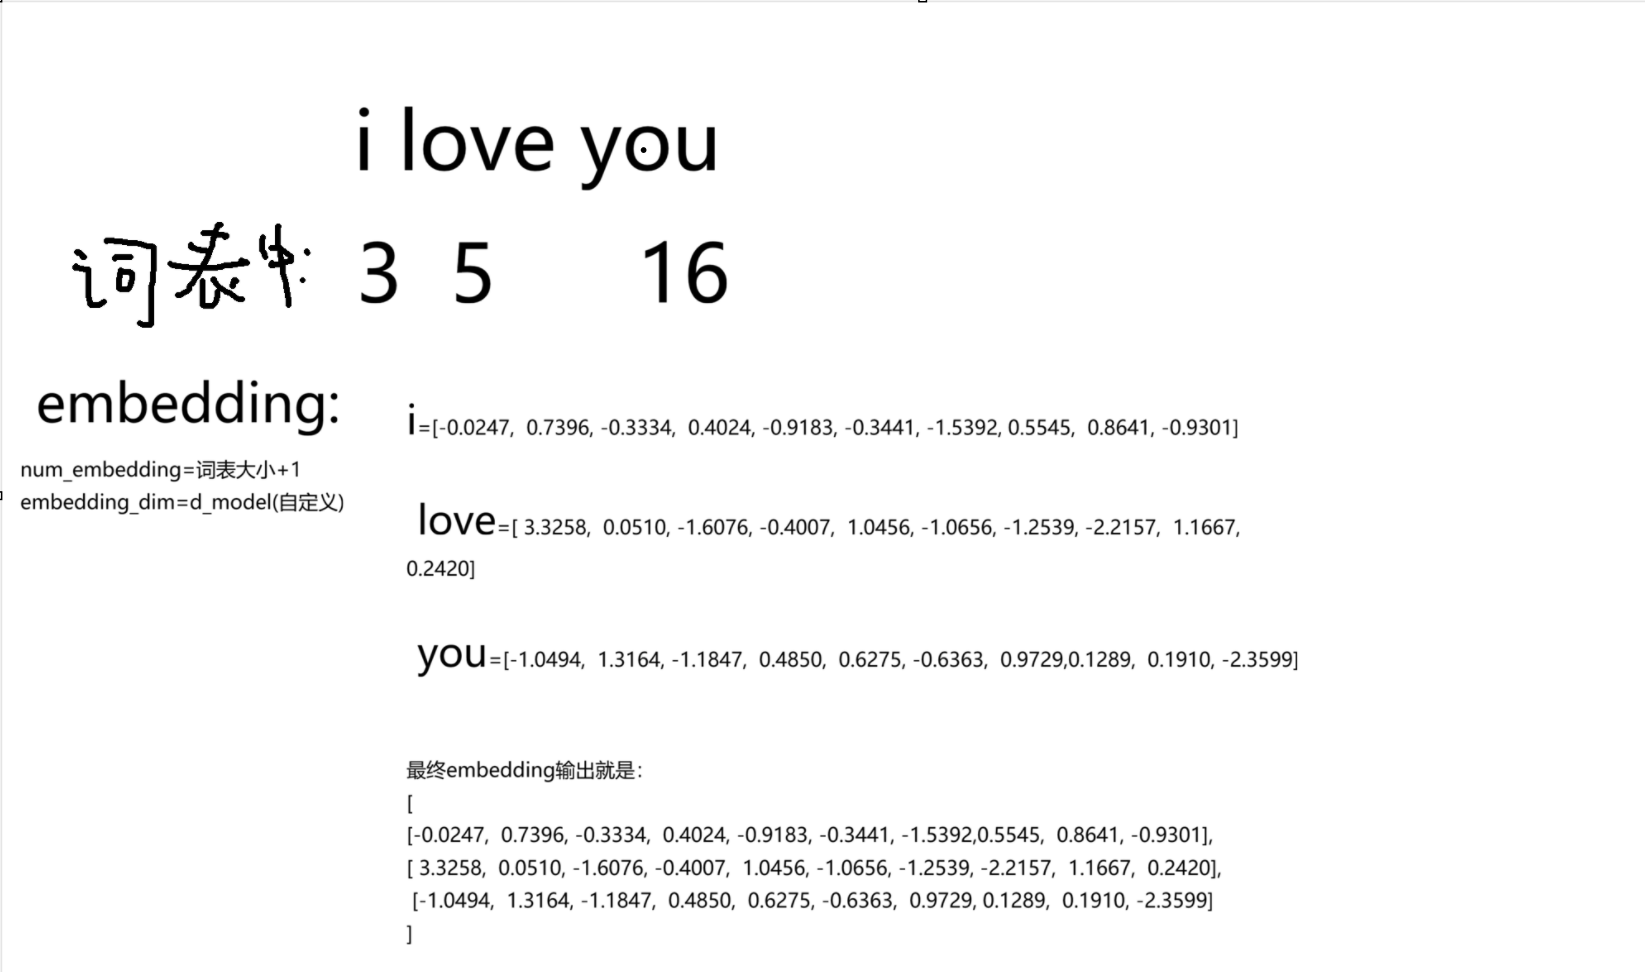

In [ ]:
embedding=nn.Embedding(num_embeddings=vocab_size+1,embedding_dim=10) 
show_embedding=embedding(x)
show_embedding#这里可以看出第一个维度dim0是batch_size(此处为整个，没细分batch)，x真实shape是dim1、dim2


'''
维度问题：按流程
识别token后，input维度为（batch,len）,len指的是一句话中所有token翻译为词表中索引后的长度，也就是一句话中含的token数
对词表索引列表形式执行embedding后：维度变为（batch,len,embedding_dim） 将每一个词表索引重新由单个数设置为embedding层设置的embedding_dim=10，原来的一行输入会变成一个矩阵
'''
show_embedding

In [ ]:
#hyper parameters
d_model=100
d_k=64
d_v=64
lr=1e-2
epochs=4000


### 如果要使用casual musk:
### 在QK/sqrt(dk)运算之后，再按元素加一个矩阵，这个矩阵其中上半三角为"-∞" 这样可以使softmax的时候对应mask的位置概率为0，下半三角为0
不用乘法是因为-inf无法相乘
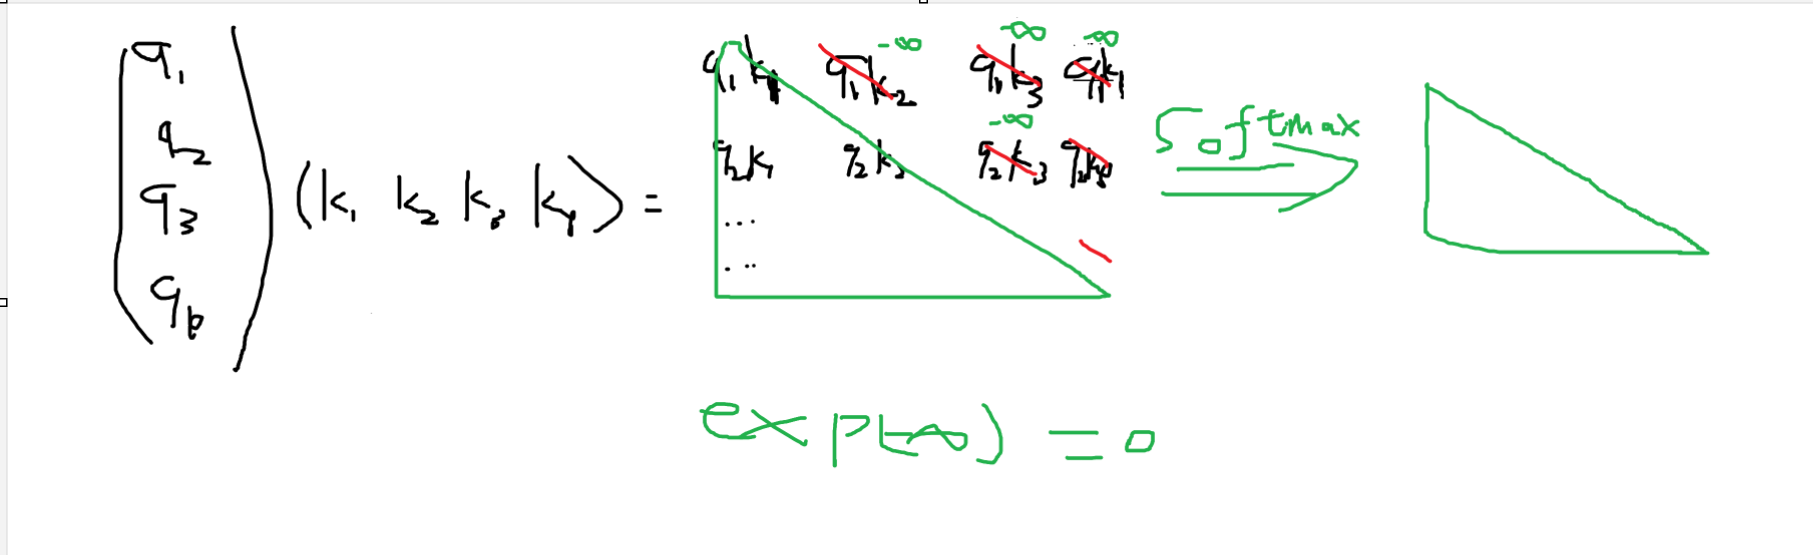

In [ ]:
def Attention(Q,K,V):
#   alpha=torch.softmax((Q@K.transpose(-2,-1))/(d_k**0.5),dim=-1)#需要指定转置（qkv均为三维（含batch）），需要指定按行softmax
#加上casule mask:
    _,N,_=Q.shape
    mask=torch.tril(torch.ones(N,N))#tril生成下三角
    #再将所有0位置替换为布尔无穷小
    mask=mask.masked_fill(mask == 0, float('-inf'))
    #再将所有1替换为布尔0
    mask=mask.masked_fill(mask==1,0.0)

    
    #print( (Q.shape,N))  15*4*64      4
    #print( (Q@K.transpose(-2,-1)).shape,N)   15*4*4     4

    alpha=torch.softmax((Q@K.transpose(-2,-1))/(d_k**0.5)+mask,dim=-1)
    h=alpha@V
    return h

### for循环实现positional embedding

In [ ]:
import math
class PositionalEmbed(nn.Module):
    def __init__(self,d_model,pos,base=10000,dropout=0.1):#embedding 后的x维度恰好是d_model，pos为序列最大长度（也就是每句tokens长度）
        super().__init__()
        self.dropout=nn.Dropout(p=dropout)#Dropout模块
        e=torch.zeros(pos,d_model)
        #由于x是每句tokens一个小的二维（整个x是三维（B,L,embeddim）），所以e也是小二维即可
        for p in range(pos):
            for i in range(d_model//2):
                    e[p][2*i]=math.sin(p/base**(2*i/d_model))
                    e[p][2*i+1]=math.cos(p/base**(2*i/d_model))

        self.register_buffer('e',e)#将init中的局部变量e变为全局

    def forward(self,x):#forward函数负责将计算好的位置编码加到embedding(x)上,
        #因为nn.Module机制规定只有forward函数里的操作才能参与反向传播，追踪梯度
        x=x+self.e[:x.size(1)]#为了追踪这个加法的梯度
        x=self.dropout(x)
        return x
        


### 向量方法先得角度矩阵再偶数取sin，奇数取cos计算
循环实现的代码确实更贴近数学公式的逐字翻译，读起来像伪代码一样直观。而向量化版本需要理解广播、切片、对数变换等技巧，初次接触会觉得绕  
不过在实际工程中，向量化有两个循环无法替代的优势：  
#### 1.*性能差距巨大*  
当 max_len=5000、d_model=512 时，双层循环需要执行约 256 万次 Python 级别的迭代，而向量化版本只需要几次底层 C++ 运算。训练大模型时，每次前向都调用位置编码，累计的时间差异非常可观。  
#### 2.*可维护性与灵活性*  
向量化代码一旦写好，修改参数（如 base、d_model）不需要调整循环逻辑。而循环代码如果要支持动态 max_len 或不同的 d_model，需要小心边界条件

In [ ]:
import math
class PositionalEmbed(nn.Module):
    def __init__(self,d_model,pos,base=10000,dropout=0.1):#embedding 后的x维度恰好是d_model，pos为序列最大长度（也就是每句tokens长度）
        super().__init__()
        self.dropout=nn.Dropout(p=dropout)#Dropout模块
        
        #position向量：
        p=torch.arange(0,pos,dtype=torch.float) #保证是float向量
        
        #角度向量:先生成等差的指数部分，再整体exp，否则无法直接生成
        #angle=torch.arange(0,-0.5*math.log(base),-2/d_model*math.log(base))
        factor=torch.arange(0,(d_model+1)//2,dtype=torch.float)
        factor=(-2/d_model*math.log(base))*factor
        factor=torch.exp(factor)

        angle=torch.matmul(p.unsqueeze(1),factor.unsqueeze(0))#torch的一维向量没有行列概念，所有一维向量相乘都只有内积，所以需要使用unsqueeze函数
        #（pos,）是一维，pytorch中一维向量没有行列之分，（pos,1）就是二维了（列矩阵）
        #matmul对一维向量执行点积，对二维向量执行矩阵乘法
        #可以使用 .reshape(pos, 1) 或 .view(pos, 1) 将一维张量 (pos,) 转换为二维列向量 (pos, 1)。这两种方法与 .unsqueeze(1) 的效果等价，都是增加一个维度。
        
        pe=torch.zeros(pos,d_model)
        pe[:,0::2]=torch.sin(angle)#0::2表示从0开始每隔两个取一个    #对整个e做出预修改然后取用
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(angle)
        else:
            pe[:, 1::2] = torch.cos(angle[:, :d_model//2]) 

        self.register_buffer('pe',pe)#将init中的局部变量e变为全局

        
    def forward(self,x):#forward函数负责将计算好的位置编码加到embedding(x)上,
                          #因为nn.Module机制规定只有forward函数里的操作才能参与反向传播，追踪梯度
        x=x+self.pe[:x.size(1)]#为了追踪这个加法的梯度
        x=self.dropout(x)
        return x   





#可视化
import matplotlib.pyplot as plt

# 假设你已经实例化了 PositionalEmbed
pos_embed = PositionalEmbed(d_model=128, pos=50)  # 小维度便于观察
pe = pos_embed.pe.cpu().numpy()

plt.figure(figsize=(10, 6))
plt.imshow(pe, aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Heatmap')
plt.show()
        

### 自注意力模型输入X有k个向量，输出H也就有k个向量，只是自回归任务只取用最后一个来输出下一个token
### module中有一个线性层，将embedding后形式的输出h再映射回词表大小的维度，得到一个与词表同长的“是各词的概率”向量，以便于CrossEntropyLoss计算代价

In [ ]:
_,pos=x.shape        
pos#每句tokens长度 
    

class TextGen(nn.Module):
    def __init__(self,vocab_size,d_model,d_k,d_v):
        super().__init__()
        #embedding层在对照单词表将每一个token转换为一个d_model维度的向量，向量内容会在训练中更新
        self.embedding=nn.Embedding(num_embeddings=vocab_size+1,embedding_dim=d_model)  #num_embedding是词表编号范围，从0开始
        self.positionembed=PositionalEmbed(d_model=d_model,pos=pos)
        self.w_q=nn.Linear(d_model,d_k)  #所有各类长度的token已经被embedding统一为同一个维度d_model
        self.w_k=nn.Linear(d_model,d_k)
        self.w_v=nn.Linear(d_model,d_v)  #这三个是并行计算的，而不是sequential

        self.output_proj=nn.Linear(d_v,vocab_size+1)#将最后的输出映射回词表大小！！！！！！！！！！！！
        #理解这个设计哲学：也可以将d_v本身设置为vocab_size+1
    
    
    def forward(self,x):
        x=self.embedding(x)
        e=self.positionalembed(x)
        Q=self.w_q(x)
        K=self.w_k(x)
        V=self.w_v(x)

        h=Attention(Q,K,V)
        last_h = h[:, -1, :] 
        logits = self.output_proj(last_h)
        return logits



model=TextGen(vocab_size,d_model,d_k,d_v)

In [ ]:
#数据准备
x_train=x[:,:-1]
y_train=x[:,1:]
print("x_train shape:", x_train.shape)  # (5 最大长度)
print("y_train shape:", y_train.shape)


In [ ]:
y_train.shape

In [ ]:
# 假设你已经有了这些：
# model: 你的模型
# x_train: (4, 2) 整数 token ID
# y_train: (4, 2) 整数 token ID

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in tqdm(range(epochs)):
    # 1. 前向传播：输入整数ID，输出每个位置对每个词的得分
    logits = model(x_train)        # (4, 2, vocab_size+1)
    
    # 2. 算 loss：把预测和真实目标比较
    # 需要把 logits 和 y_train 展平成二维才能算
    loss = criterion(logits, y_train[:, -1])
    
    
    # 3. 反向传播 + 更新参数
    optimizer.zero_grad()   # 清空上一步的梯度
    loss.backward()         # 计算梯度
    optimizer.step()        # 更新参数
    
    if (epoch + 1) % 1000 == 0:
        print(f"epoch {epoch+1}, loss: {loss.item():.4f}")

In [ ]:

while 1:
    string=input("输入多个词").split()#split可以实现接收按空格分隔的数据为一个列表
    
    indices = [vocab.get(word, vocab.get('<unk>', 0)) for word in string]  # 处理未知词
    test_input = torch.tensor([indices])
    logits = model(test_input)
    pred_idx = logits.argmax(dim=-1).item()

    # 把预测的索引转回词
    idx2word = {idx: word for word, idx in vocab.items()}
    print("输入: ",string)
    print("模型预测的下一个词:", idx2word[pred_idx])

输入多个词 wind blows


输入:  ['wind', 'blows']
模型预测的下一个词: strong


输入多个词 cold through


输入:  ['cold', 'through']
模型预测的下一个词: air


输入多个词 sir


...

输入:  ['love', 'makes']
模型预测的下一个词: living


输入多个词 love make life


输入:  ['love', 'make', 'life']
模型预测的下一个词: living


输入多个词 wind


输入:  ['wind']
模型预测的下一个词: strong


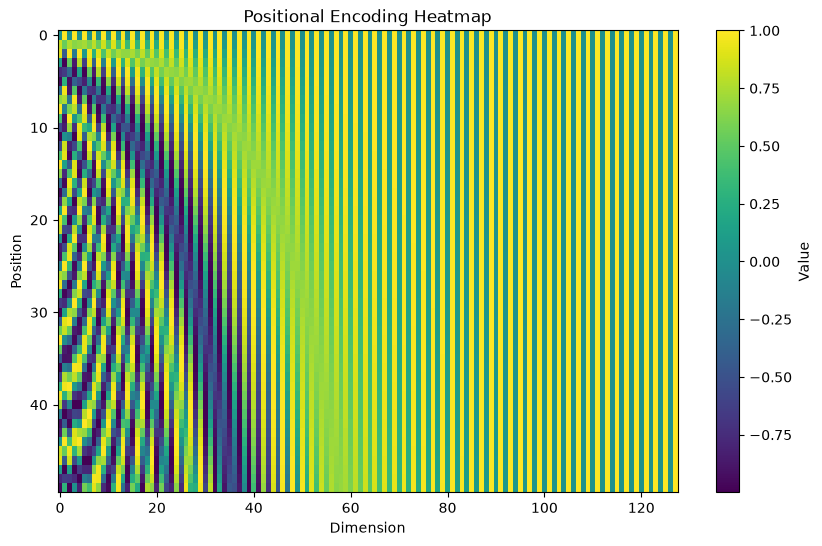

In [ ]:
while True:
    raw = input("输入多个词: ").strip().split()
    if not raw: continue
    indices = [vocab.get(w, vocab.get('<unk>', 0)) for w in raw]
    print("实际输入索引:", indices)                    # 检查索引是否合理
    test_input = torch.tensor([indices])
    with torch.no_grad():
        logits = model(test_input)
    print("logits shape:", logits.shape)               # 检查输出形状
    print("logits 最大值位置:", logits.argmax(dim=-1)) # 检查是否总在同一位置
    pred_idx = logits.argmax(dim=-1).item()
    idx2word = {idx: word for word, idx in vocab.items()}
    print("预测词:", idx2word.get(pred_idx, '<OOV>'))